In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
df.head()
df.info()
df.describe()
df.tail()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


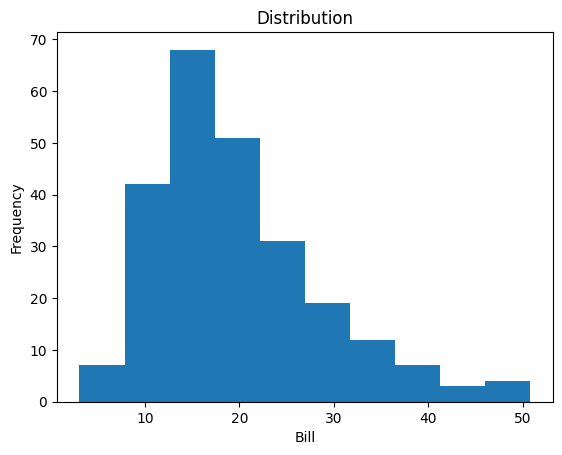

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['total_bill'])
plt.title("Distribution")
plt.xlabel("Bill")
plt.ylabel("Frequency")
plt.show()

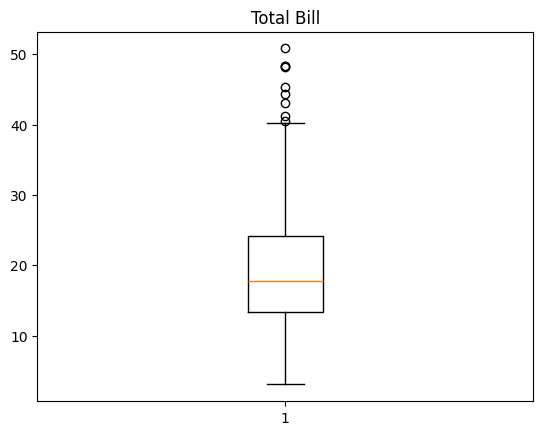

In [6]:
plt.boxplot(df['total_bill'])
plt.title("Total Bill")
plt.show()

In [13]:
import seaborn as sns

sns.heatmap(df.corr(),annot=True)
plt.title("total_bill")
plt.show()

ValueError: could not convert string to float: 'Female'

In [10]:
print(df.isnull().sum())

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


In [11]:
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['total_bill'] >= lower) & (df['total_bill'] <= upper)]

In [12]:
print(df.shape)
print(df_clean.shape)

(244, 7)
(235, 7)


In [14]:
print("Treatment")
print(df['total_bill'].describe())
print(df_clean['total_bill'].describe())

Treatment
count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64
count    235.000000
mean      18.798681
std        7.438468
min        3.070000
25%       13.215000
50%       17.460000
75%       23.135000
max       40.170000
Name: total_bill, dtype: float64


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['total_bill_scaled'] = scaler.fit_transform(df[['total_bill']])

print(df[['total_bill', 'total_bill_scaled']].describe())

       total_bill  total_bill_scaled
count  244.000000       2.440000e+02
mean    19.785943      -7.871663e-17
std      8.902412       1.002056e+00
min      3.070000      -1.881547e+00
25%     13.347500      -7.247111e-01
50%     17.795000      -2.241005e-01
75%     24.127500       4.886857e-01
max     50.810000       3.492068e+00


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['total_bill']]
y = df['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [0.10696371]
Intercept: 0.9252355585570546
